# ISDS 7075 Summer 2026 - Group 4 Project

## Chronic Kidney Disease Analysis

### Group Members: Thais Diaz, Cody Tatom, Rhonda Swider

## Wrangling of Data

In [2]:
#Import required packages

import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

#Figures inline and set visualization style
%matplotlib inline
sns.set()


### Import the data

In [3]:
df_kd = pd.read_excel("../data/ML_project_kidney_disease.xlsx")
df_kd_fields = pd.read_excel("../data/ML_project_kidney_disease.xlsx", sheet_name = "Fields")

In [4]:
df_kd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

### Identify Missing Values
Total number of rows is 400. 
Missing values in almost all fields.  


In [5]:
df_kd.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,wc,rc,htn,dm,cad,appet,pe,ane,classification,CKD_class
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,7800,5.2,yes,yes,no,good,no,no,ckd,1
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,6000,NaN,no,no,no,good,no,no,ckd,1
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,7500,NaN,no,yes,no,poor,no,yes,ckd,1
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,6700,3.9,yes,no,no,poor,yes,yes,ckd,1
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,7300,4.6,no,no,no,good,no,no,ckd,1


### Investigate Data Structure/dictionary
The dta structure/dictionary from reference info on website 
shows information about the Description, Type, and value info.
This information pulls in from the second sheettab appended in the
Excel data file.

In [6]:
df_kd_fields

,Name,Description,Type,value_info
0,age,age,Integer,age in years
1,bp,blood pressure,Integer,bp in mm/Hg
2,sg,specific gravity,Categorical,"1.005,1.010,1.015,1.020,1.025"
3,al,albumin,Categorical,"0,1,2,3,4,5"
4,su,sugar,Categorical,"0,1,2,3,4,5"
5,rbc,red blood cells,Binary,"normal,abnormal"
6,pc,pus cell,Binary,"normal,abnormal"
7,pcc,pus cell clumps,Binary,"present,notpresent"
8,ba,bacteria,Binary,"present,notpresent"
9,bgr,blood gluucose random,Integer,bgr in mgs/dl


In [7]:
df_kd.describe()


,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,CKD_class
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,400.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,0.620000
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,0.485994
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,0.000000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,0.000000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,1.000000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,1.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,1.000000


### Adjust for Missing values

In [8]:
#Find all "?" values, and replace with the np.nan function
df_kd.replace('?',np.nan,inplace=True)

print(df_kd.isnull().sum())

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
CKD_class           0
dtype: int64


## Clean Missing Values by applying mean or mode, depending upon type

In [9]:
# Compute average age
avg_age = df_kd['age'].mean()

print(f"Average age: {avg_age:.0f}")

# Fill missing values with the average
df_kd['age'] = df_kd['age'].fillna(avg_age)

# Convert to integer
df_kd['age'] = df_kd['age'].astype(int)

Average age: 51


In [10]:
# Compute average bp
avg_bp = df_kd['bp'].mean()
print("Average bp:", avg_bp)
# Replace NaN with mean and convert to int
df_kd['bp'] = df_kd['bp'].fillna(avg_bp).astype(int)


Average bp: 76.46907216494846


In [11]:
# Find the mode of sg
mode_sg = df_kd['sg'].mode()[0]
print("Mode sg:", mode_sg)

# Fill missing values with the mode
df_kd['sg'] = df_kd['sg'].fillna(mode_sg)


Mode sg: 1.02


In [12]:
mode_al = df_kd['al'].mode()[0]
print("Mode al:", mode_al)

# Fill missing values with the mode
df_kd['al'] = df_kd['al'].fillna(mode_al)

Mode al: 0.0


In [13]:
mode_su = df_kd['su'].mode()[0]
print("Mode su:", mode_su)

# Fill missing values with the mode
df_kd['su'] = df_kd['su'].fillna(mode_su)

Mode su: 0.0


In [14]:
# Find mode
mode_rbc = df_kd['rbc'].mode()[0]
print("Mode rbc:", mode_rbc)

# Fill missing values
df_kd['rbc'] = df_kd['rbc'].fillna(mode_rbc)

Mode rbc: normal


In [15]:
# pc is missing 65 values - Replace with mode

# Find mode
mode_pc = df_kd['pc'].mode()[0]
print("Mode pc:", mode_pc)

# Fill missing values with mode
df_kd['pc'] = df_kd['pc'].fillna(mode_pc)


Mode pc: normal


In [16]:
# pcc is missing 4 values - Replace with mode

# Find mode
mode_pcc = df_kd['pcc'].mode()[0]
print("Mode pcc:", mode_pcc)

# Fill missing values with mode
df_kd['pcc'] = df_kd['pcc'].fillna(mode_pcc)


Mode pcc: notpresent


In [17]:
# ba is missing 4 values - Replace with mode

# Find mode
mode_ba = df_kd['ba'].mode()[0]
print("Mode ba:", mode_ba)

# Fill missing values with mode
df_kd['ba'] = df_kd['ba'].fillna(mode_ba)


Mode ba: notpresent


In [18]:
# bgr is missing 44 values - Replace with average bgr and convert to int

# Compute average bgr
avg_bgr = df_kd['bgr'].mean()
print("Average bgr:", avg_bgr)

# Fill missing values and convert to int
df_kd['bgr'] = df_kd['bgr'].fillna(avg_bgr).astype(int)


Average bgr: 148.0365168539326


In [19]:
# bu is missing 19 values - Replace with average bu and convert to int

# Compute average bu
avg_bu = df_kd['bu'].mean()
print("Average bu:", avg_bu)

# Fill missing values and convert to int
df_kd['bu'] = df_kd['bu'].fillna(avg_bu).astype(int)


Average bu: 57.425721784776904


In [20]:
# sc is missing 17 values - Replace with average sc and keep as float

# Compute average sc
avg_sc = df_kd['sc'].mean()
print("Average sc:", avg_sc)

# Fill missing values
df_kd['sc'] = df_kd['sc'].fillna(avg_sc).astype(float)



Average sc: 3.072454308093995


In [21]:
# sod missing 87 values - Replace with mean and convert to int

# Compute average sod
avg_sod = df_kd['sod'].mean()
print("Average sod:", avg_sod)

# Fill missing values and convert to int
df_kd['sod'] = df_kd['sod'].fillna(avg_sod).astype(int)


Average sod: 137.52875399361022


In [22]:
# pot missing 88 values - Replace with mean and convert to int

# Compute average pot
avg_pot = df_kd['pot'].mean()
print("Average pot:", avg_pot)

# Fill missing values and convert to int
df_kd['pot'] = df_kd['pot'].fillna(avg_pot).astype(int)


Average pot: 4.62724358974359


In [23]:
# hemo missing 52 values - Replace with mean and convert to int

# Compute average hemo
avg_hemo = df_kd['hemo'].mean()
print("Average hemo:", avg_hemo)

# Fill missing values and convert to int
df_kd['hemo'] = df_kd['hemo'].fillna(avg_hemo).astype(int)


Average hemo: 12.526436781609195


In [24]:
# pcv missing 70 values -- Replace with mean

# Convert '?' to NaN and ensure numeric type
df_kd['pcv'] = df_kd['pcv'].replace('?', np.nan)
df_kd['pcv'] = pd.to_numeric(df_kd['pcv'], errors='coerce')

# Compute mean
avg_pcv = df_kd['pcv'].mean()
print("Average pcv:", avg_pcv)

# Fill missing values with mean
df_kd['pcv'] = df_kd['pcv'].fillna(avg_pcv)

# Convert to int
df_kd['pcv'] = df_kd['pcv'].round().astype(int)


Average pcv: 38.88449848024316


In [25]:
# wc missing 105 values -- Replace with mean

# Convert '?' to NaN and ensure numeric type
df_kd['wc'] = df_kd['wc'].replace('?', np.nan)
df_kd['wc'] = pd.to_numeric(df_kd['wc'], errors='coerce')

# Compute mean
avg_wc = df_kd['wc'].mean()
print("Average wc:", avg_wc)

# Fill missing values with mean
df_kd['wc'] = df_kd['wc'].fillna(avg_wc)

# Convert to int 
df_kd['wc'] = df_kd['wc'].round().astype(int)


Average wc: 8406.122448979591


In [26]:
# rc missing 130 values -- Replace with mean

# Convert '?' to NaN and ensure numeric type
df_kd['rc'] = df_kd['rc'].replace('?', np.nan)
df_kd['rc'] = pd.to_numeric(df_kd['rc'], errors='coerce')

# Compute mean
avg_rc = df_kd['rc'].mean()
print("Average rc:", avg_rc)

# Fill missing values with mean
df_kd['rc'] = df_kd['rc'].fillna(avg_rc)


Average rc: 4.707434944237917


In [27]:
# htn missing 2 values -- Replace with mode

# Find mode
mode_htn = df_kd['htn'].mode()[0]
print("Mode htn:", mode_htn)

# Fill missing values with mode
df_kd['htn'] = df_kd['htn'].fillna(mode_htn)


Mode htn: no


In [28]:
# dm missing 2 values - Clean inconsistent values and replace missing values

# Fix formatting issues
df_kd['dm'] = df_kd['dm'].replace({
    ' yes': 'yes',
    '\tyes': 'yes',
    '\tno': 'no'
})

# Find mode
mode_dm = df_kd['dm'].mode()[0]
print("Mode dm:", mode_dm)

# Fill missing values with mode
df_kd['dm'] = df_kd['dm'].fillna(mode_dm)


Mode dm: no


In [29]:
# cad missing 2 values -- Replace with mode

# Find mode
mode_cad = df_kd['cad'].mode()[0]
print("Mode cad:", mode_cad)

# Fill missing values with mode
df_kd['cad'] = df_kd['cad'].fillna(mode_cad)


Mode cad: no


In [30]:
# appet missing 1 value -- Replace with mode

# Find mode
mode_appet = df_kd['appet'].mode()[0]
print("Mode appet:", mode_appet)

# Fill missing values with mode
df_kd['appet'] = df_kd['appet'].fillna(mode_appet)


Mode appet: good


In [31]:
# pe missing 1 value -- Replace with mode

# Find mode
mode_pe = df_kd['pe'].mode()[0]
print("Mode pe:", mode_pe)

# Fill missing values with mode
df_kd['pe'] = df_kd['pe'].fillna(mode_pe)


Mode pe: no


In [32]:
# ane missing 1 value -- Replace with mode

# Find mode
mode_ane = df_kd['ane'].mode()[0]
print("Mode ane:", mode_ane)

# Fill missing values with mode
df_kd['ane'] = df_kd['ane'].fillna(mode_ane)


Mode ane: no


In [33]:
# classification had an erroneous value 'ckd\t' - correct it

df_kd['classification'] = df_kd['classification'].replace('ckd\t', 'ckd')


### Recheck data info to make sure all missing items are clean

In [34]:
df_kd.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             400 non-null    int32  
 2   bp              400 non-null    int32  
 3   sg              400 non-null    float64
 4   al              400 non-null    float64
 5   su              400 non-null    float64
 6   rbc             400 non-null    object 
 7   pc              400 non-null    object 
 8   pcc             400 non-null    object 
 9   ba              400 non-null    object 
 10  bgr             400 non-null    int32  
 11  bu              400 non-null    int32  
 12  sc              400 non-null    float64
 13  sod             400 non-null    int32  
 14  pot             400 non-null    int32  
 15  hemo            400 non-null    int32  
 16  pcv             400 non-null    int32  
 17  wc              400 non-null    int

### Correct data format
CKD_class should be binary, which would be better represented as 'str'

In [35]:
df_kd['CKD_class'] = df_kd['CKD_class'].astype('str')
df_kd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             400 non-null    int32  
 2   bp              400 non-null    int32  
 3   sg              400 non-null    float64
 4   al              400 non-null    float64
 5   su              400 non-null    float64
 6   rbc             400 non-null    object 
 7   pc              400 non-null    object 
 8   pcc             400 non-null    object 
 9   ba              400 non-null    object 
 10  bgr             400 non-null    int32  
 11  bu              400 non-null    int32  
 12  sc              400 non-null    float64
 13  sod             400 non-null    int32  
 14  pot             400 non-null    int32  
 15  hemo            400 non-null    int32  
 16  pcv             400 non-null    int32  
 17  wc              400 non-null    int


### Data Normalization

### Binning

In [36]:
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20', '21-40', '41-60', '61-80', '81+']

df_kd['Age_Group'] = pd.cut(
    df_kd['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

### Visualizations

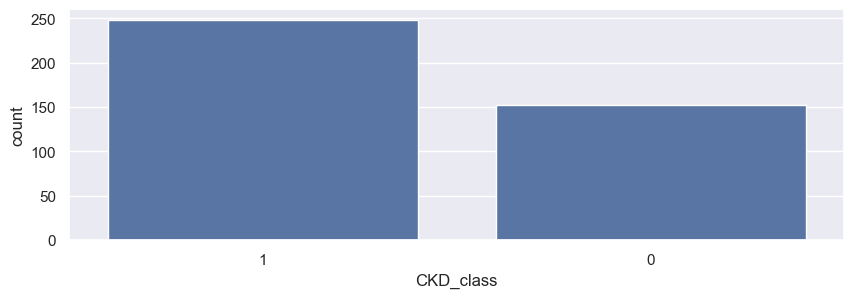

In [37]:
plt.figure(figsize=(10,3))
sns.countplot(x=df_kd['CKD_class'])
plt.show()

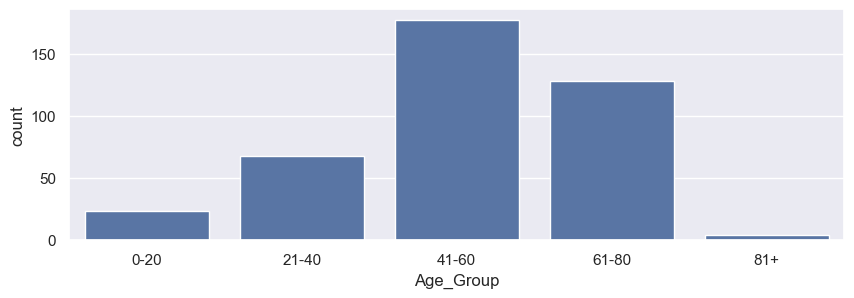

In [38]:
plt.figure(figsize=(10,3))
sns.countplot(x=df_kd['Age_Group'])
plt.show()

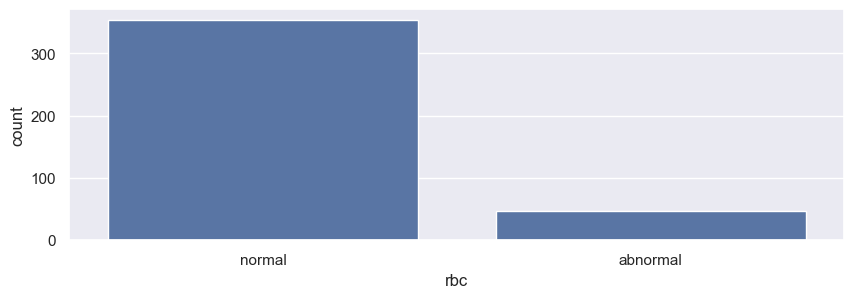

In [39]:
plt.figure(figsize=(10,3))
sns.countplot(x=df_kd['rbc'])
plt.show()

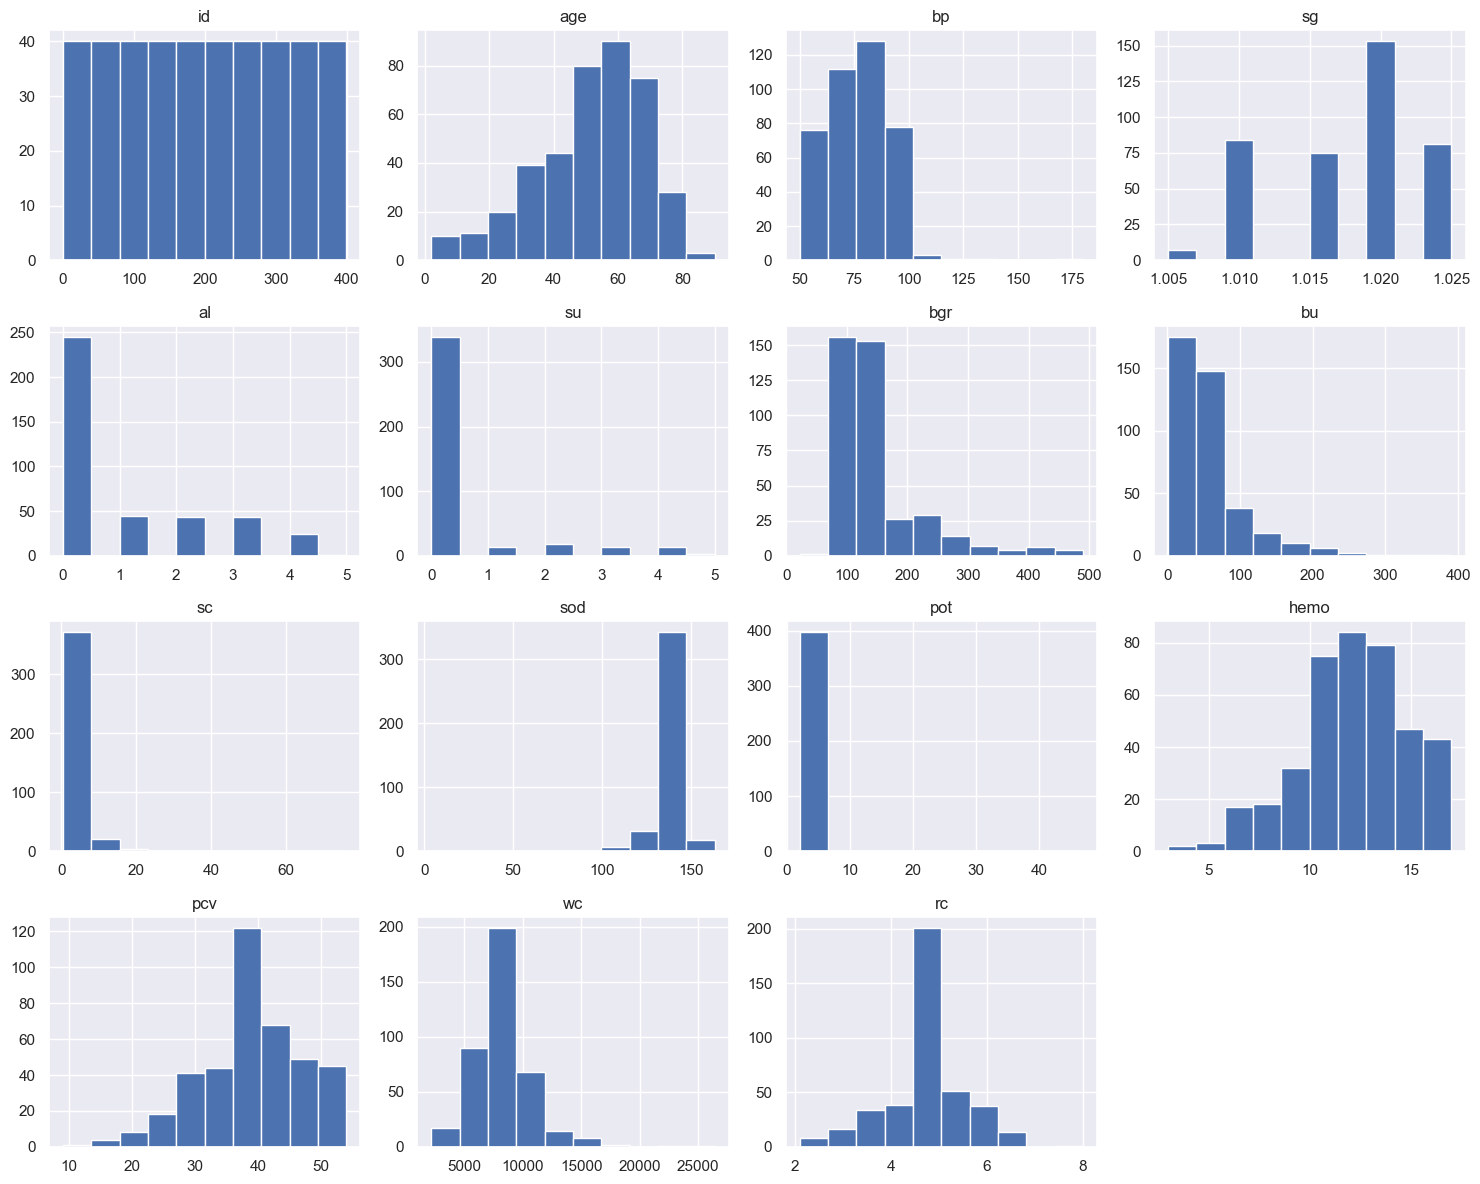

In [40]:
df_kd.hist(figsize=(15,12))

plt.tight_layout()

plt.show()

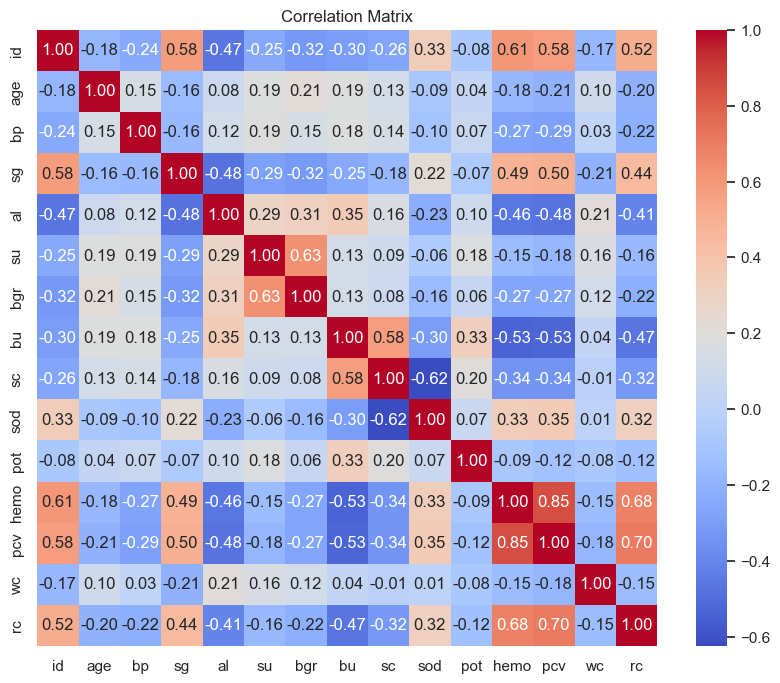

In [41]:
plt.figure(figsize=(10,8))

correlation = df_kd.corr(numeric_only=True)

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

The correlation matrix shows that several of the variables are closely related. For example, hemoglobin and packed cell volume have a strong positive correlation (0.85), while packed cell volume and red blood cell count (0.70) and hemoglobin and red blood cell count (0.68) are also strongly correlated. This supports the patterns seen in the scatter plots, where patients with CKD generally had lower values for these measurements than patients without CKD. Since these variables appear to provide similar information, future analysis may consider removing one or more of them to reduce redundancy and simplify the model. Feature selection techniques can then be used to determine which variables contribute the most to predicting chronic kidney disease.

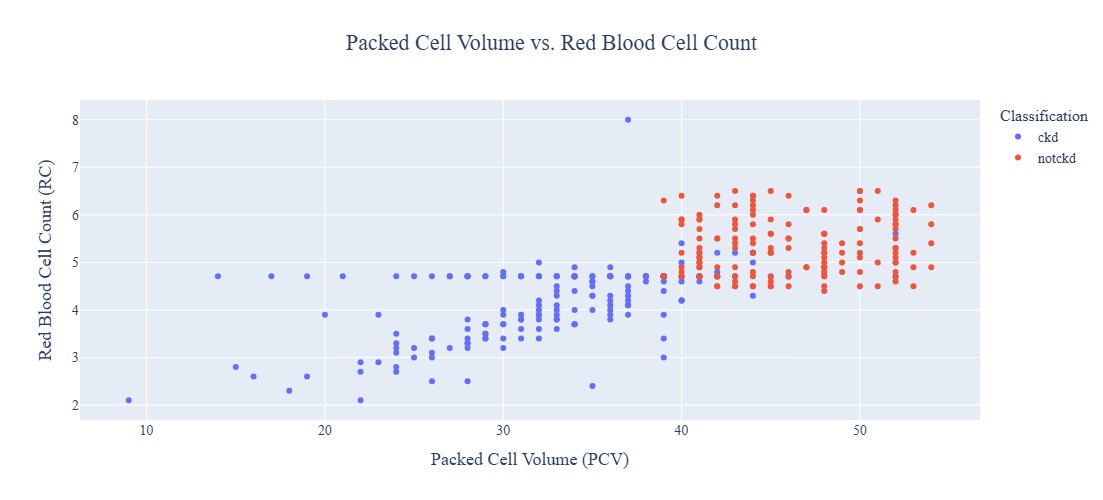

In [51]:
import plotly.express as px

fig = px.scatter(
    df_kd,
    x='pcv',
    y='rc',
    color='classification',
    title='Packed Cell Volume vs. Red Blood Cell Count',
    labels={
        'pcv': 'Packed Cell Volume (PCV)',
        'rc': 'Red Blood Cell Count (RC)',
        'classification': 'Classification'
    },
    width=700,      # Narrower figure
    height=500
)

fig.update_layout(
    font=dict(
        family='Times New Roman',
        size=14
    ),
    title=dict(
        font=dict(size=22),
        x=0.5,          # Center the title
        xanchor='center'
    ),
    xaxis_title_font=dict(size=18),
    yaxis_title_font=dict(size=18),
    legend_title_font=dict(size=16),
    legend_font=dict(size=14)
)

fig.update_xaxes(tickfont=dict(size=14))
fig.update_yaxes(tickfont=dict(size=14))

fig.show()

The Packed Cell Volume(PCV) versus Red Blood Cell Count(RC) scatter plot shows that patients with chronic kidney disease generally have lower packed cell volume (PCV) and red blood cell count (RC) values than patients without CKD. The two groups are mostly separated, which suggests that PCV and RC may be useful variables for identifying whether a patient has chronic kidney disease.

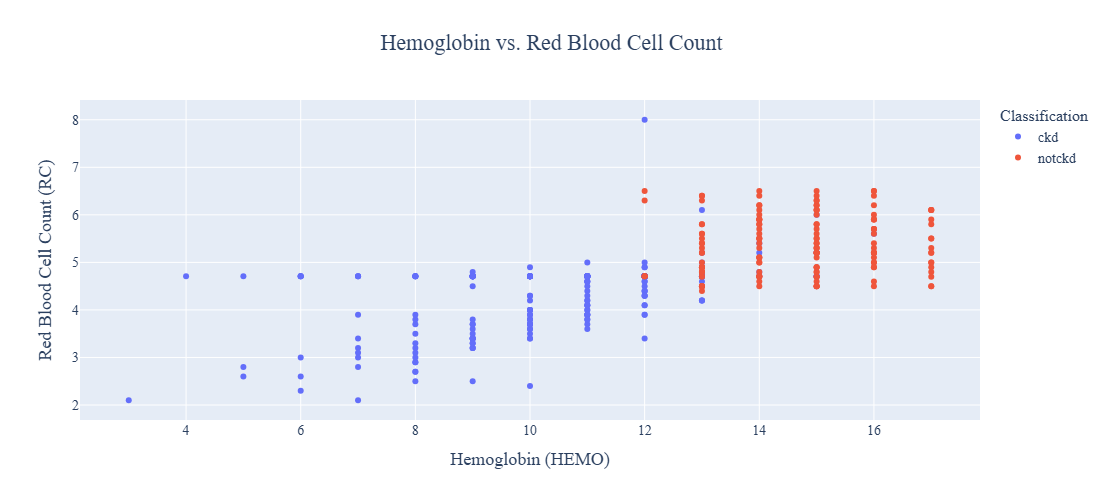

In [53]:
fig = px.scatter(
    df_kd,
    x='hemo',
    y='rc',
    color='classification',
    title='Hemoglobin vs. Red Blood Cell Count',
    labels={
        'hemo': 'Hemoglobin (HEMO)',
        'rc': 'Red Blood Cell Count (RC)',
        'classification': 'Classification'
    },
    width=700,      # Narrower figure
    height=500
)

fig.update_layout(
    font=dict(
        family='Times New Roman',
        size=14
    ),
    title=dict(
        font=dict(size=22),
        x=0.5,          # Center the title
        xanchor='center'
    ),
    xaxis_title_font=dict(size=18),
    yaxis_title_font=dict(size=18),
    legend_title_font=dict(size=16),
    legend_font=dict(size=14)
)

fig.update_xaxes(tickfont=dict(size=14))
fig.update_yaxes(tickfont=dict(size=14))

fig.show()

The scatterplot of Red Blood Cell Count(RC) as shown on the Y-axis, versus the Hemoglobin(HEMO) on the X-axis shows that patients with CKD generally have lower hemoglobin and red blood cell count values than patients without CKD. As hemoglobin increases, the red blood cell count also tends to increase. Although there is some overlap between the two groups, the pattern suggests these variables may help distinguish patients with CKD.

In [ ]:
fig = px.scatter(df_kd, x="pcv", y="wc", color="classification")
fig.show()


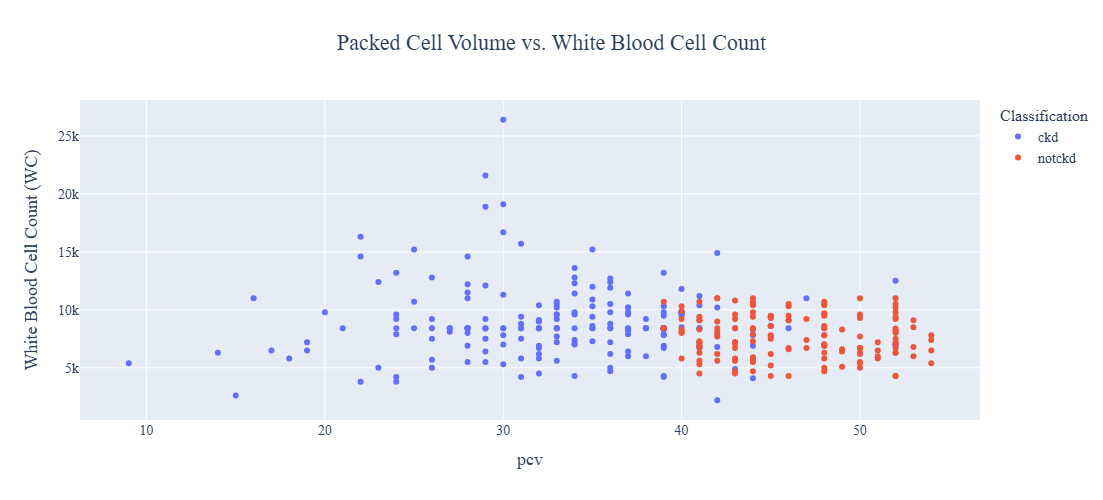

In [54]:
fig = px.scatter(
    df_kd,
    x='pcv',
    y='wc',
    color='classification',
    title='Packed Cell Volume vs. White Blood Cell Count',
    labels={
        'hemo': 'Packed Cell Volume (PCV)',
        'wc': 'White Blood Cell Count (WC)',
        'classification': 'Classification'
    },
    width=700,      # Narrower figure
    height=500
)

fig.update_layout(
    font=dict(
        family='Times New Roman',
        size=14
    ),
    title=dict(
        font=dict(size=22),
        x=0.5,          # Center the title
        xanchor='center'
    ),
    xaxis_title_font=dict(size=18),
    yaxis_title_font=dict(size=18),
    legend_title_font=dict(size=16),
    legend_font=dict(size=14)
)

fig.update_xaxes(tickfont=dict(size=14))
fig.update_yaxes(tickfont=dict(size=14))

fig.show()

The scatter plot does not show a strong relationship between packed cell volume (PCV) and white blood cell count (WC). Patients without CKD are mostly grouped at higher PCV values, while CKD patients are spread across a wider range of PCV values and show more variation in white blood cell counts, including several unusually high values. Overall, white blood cell count does not appear to separate the two groups as clearly as packed cell volume.

## Future Efforts

After completing the exploratory analysis, the next step will be to build several machine learning models and compare their results. Logistic regression, decision trees, random forests, and other ensemble models will be tested to see which one predicts chronic kidney disease most accurately. Each model will be adjusted by tuning its hyperparameters, and the results will be compared using measures such as accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices. Cross-validation and feature selection will also be used to help reduce overfitting and improve how well the models perform on new data. Comparing these models will provide a better understanding of which approach offers the best overall performance for this dataset.